<a href="https://colab.research.google.com/github/bixamtarala/ML-projects-/blob/main/loan_proacitce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# load the basic libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# load the dataset

In [4]:
df= pd.read_csv('/content/loan_approved.csv')

In [5]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Basic checks

In [6]:
df.drop(columns=['Loan_ID'],axis=1,inplace=True)

In [7]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
df.tail()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [9]:
df.columns.tolist()

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status (Approved)']

In [10]:
df.columns.str.strip().tolist()

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status (Approved)']

In [11]:
df.rename(columns={
    'LoanAmount':'Loan_Amount','ApplicantIncome':'Applicant_Income'
},inplace=True)

In [12]:
df.rename(columns={
    'CoapplicantIncome':'Coapplican_tIncome','Loan_Status (Approved)':'Loan_Status'
},inplace=True)

In [13]:
df.columns.tolist()

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Applicant_Income',
 'Coapplican_tIncome',
 'Loan_Amount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [14]:
df.describe(include='all')

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplican_tIncome,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              601 non-null    object 
 1   Married             611 non-null    object 
 2   Dependents          599 non-null    object 
 3   Education           614 non-null    object 
 4   Self_Employed       582 non-null    object 
 5   Applicant_Income    614 non-null    int64  
 6   Coapplican_tIncome  614 non-null    float64
 7   Loan_Amount         592 non-null    float64
 8   Loan_Amount_Term    600 non-null    float64
 9   Credit_History      564 non-null    float64
 10  Property_Area       614 non-null    object 
 11  Loan_Status         614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


# EDA

In [16]:
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

In [17]:
cat_cols

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [18]:
num_cols= df.select_dtypes(include=[np.number]).columns.tolist()

In [19]:
num_cols

['Applicant_Income',
 'Coapplican_tIncome',
 'Loan_Amount',
 'Loan_Amount_Term',
 'Credit_History']

# check for null values

In [20]:
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
Applicant_Income,0
Coapplican_tIncome,0
Loan_Amount,22
Loan_Amount_Term,14
Credit_History,50


#### Impute Missing Values

In [21]:
for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"Missing values in '{col}' imputed with mode.")

for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Missing values in '{col}' imputed with median.")

Missing values in 'Gender' imputed with mode.
Missing values in 'Married' imputed with mode.
Missing values in 'Dependents' imputed with mode.
Missing values in 'Self_Employed' imputed with mode.
Missing values in 'Loan_Amount' imputed with median.
Missing values in 'Loan_Amount_Term' imputed with median.
Missing values in 'Credit_History' imputed with median.


#### Verify Imputation

In [22]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
Applicant_Income,0
Coapplican_tIncome,0
Loan_Amount,0
Loan_Amount_Term,0
Credit_History,0


In [23]:
df.shape

(614, 12)

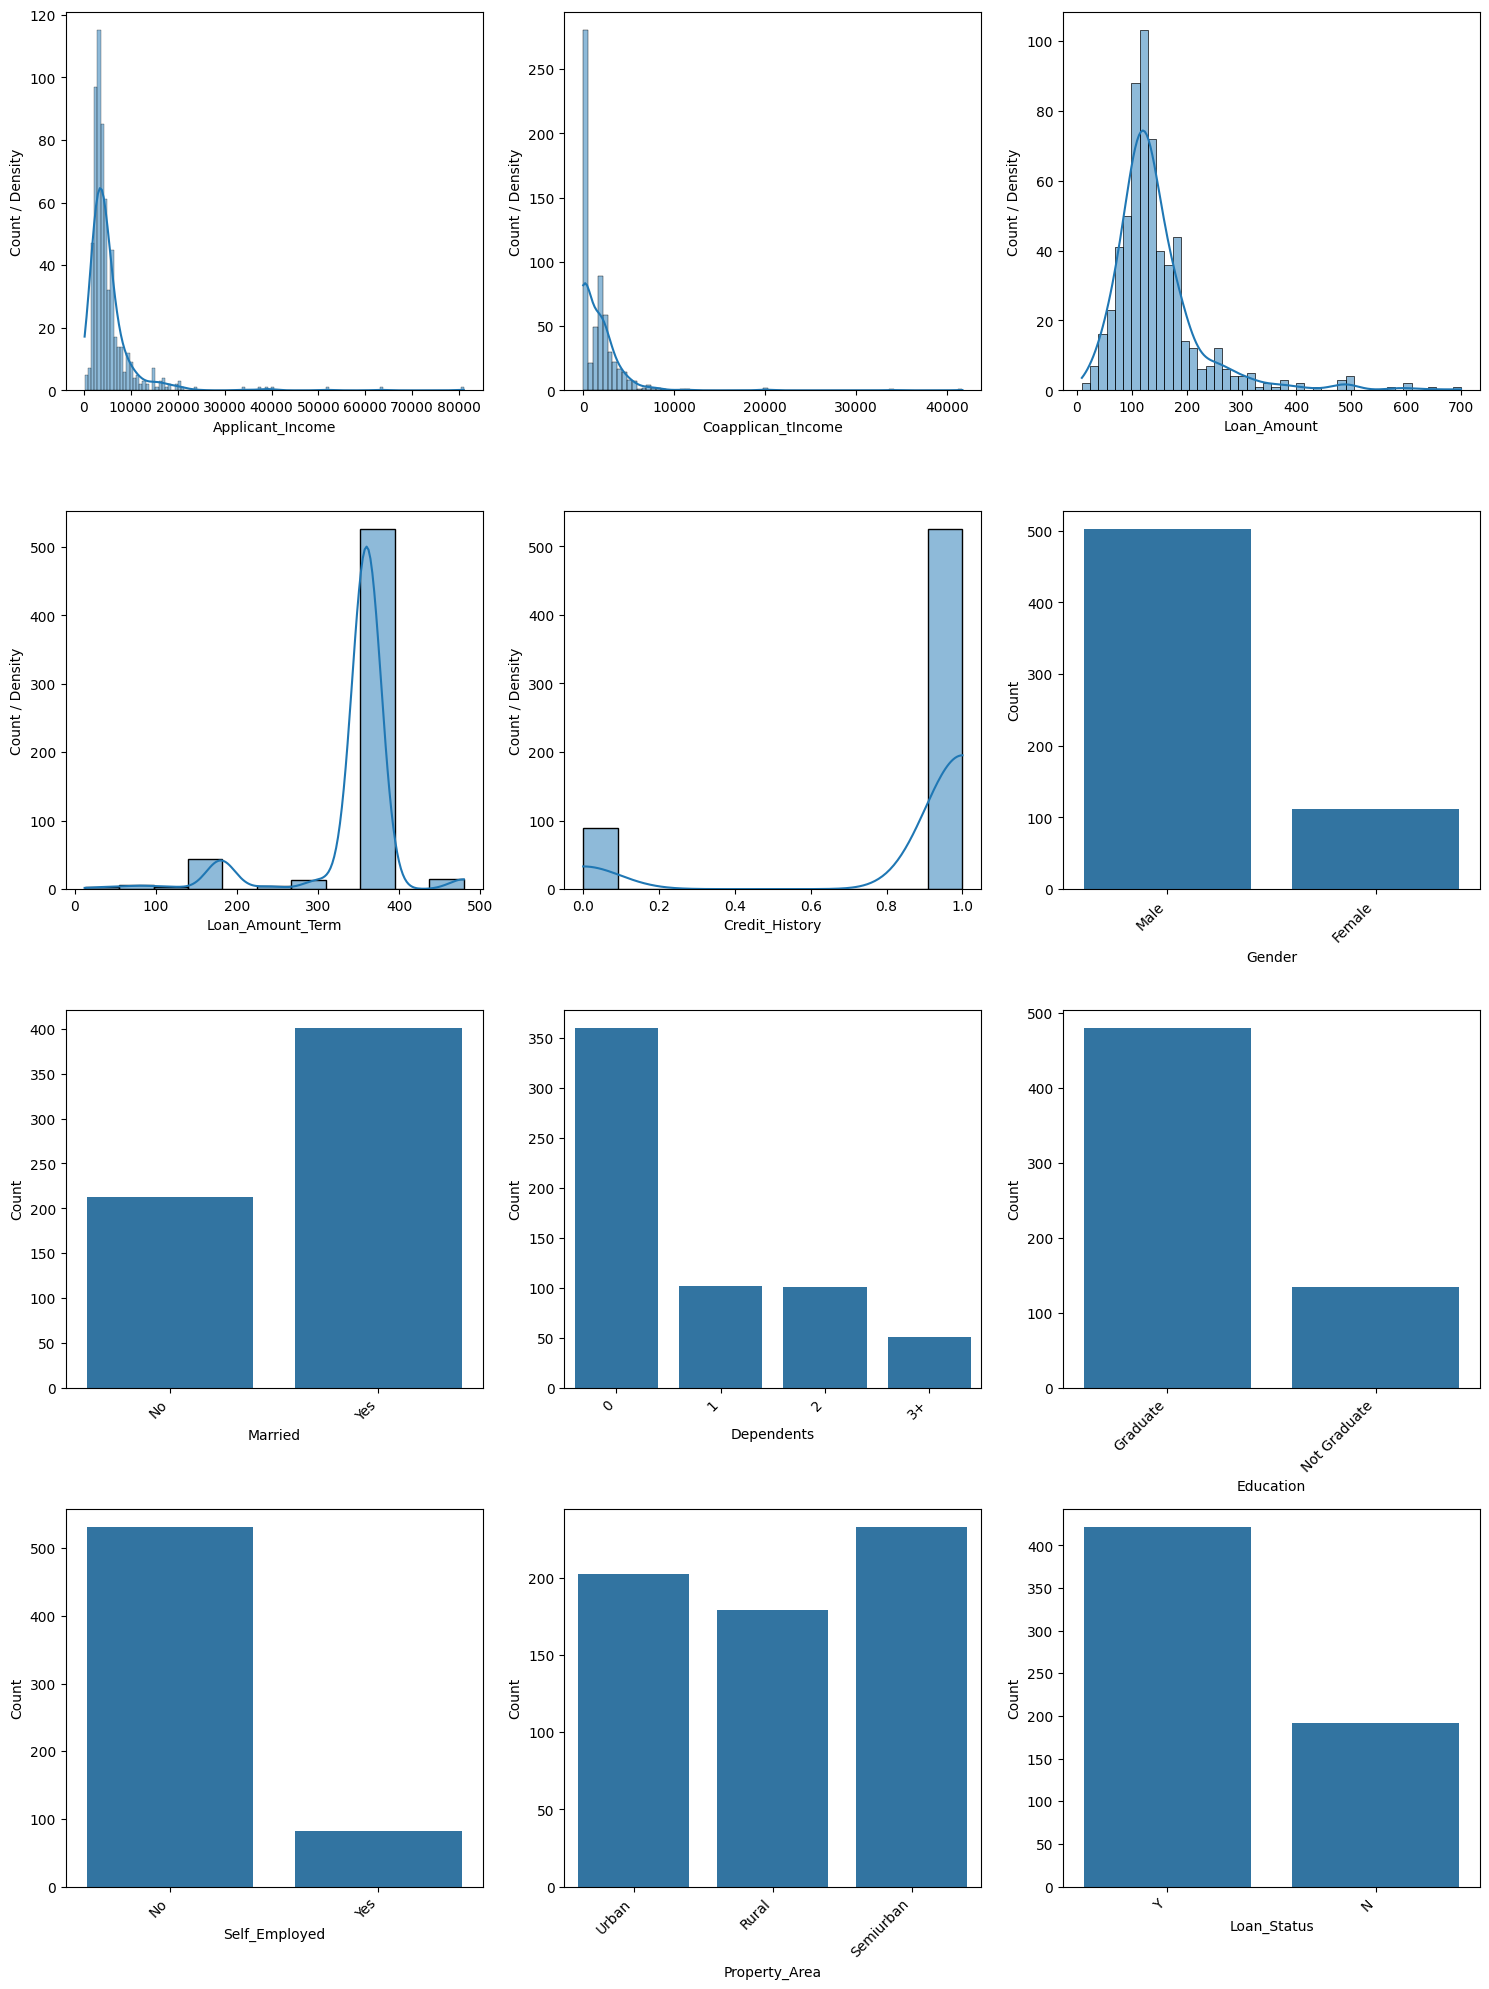

In [24]:
plt.figure(figsize=(15, 20), facecolor='white')
plotnumber = 1

# Plot numerical columns
for column in num_cols:
    if plotnumber <= 12: # Accommodate up to 12 plots in a 4x3 grid
        ax = plt.subplot(4, 3, plotnumber)
        sns.histplot(df[column], kde=True, ax=ax) # Use histplot for numerical, with KDE
        plt.xlabel(column, fontsize=10)
        plt.ylabel('Count / Density', fontsize=10)
    plotnumber += 1

# Plot categorical columns
for column in cat_cols:
    if plotnumber <= 12: # Continue plotting in the same grid
        ax = plt.subplot(4, 3, plotnumber)
        sns.countplot(x=df[column], ax=ax) # Use countplot for categorical
        plt.xlabel(column, fontsize=10)
        plt.ylabel('Count', fontsize=10)
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plotnumber += 1

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

In [25]:
# check for outliers

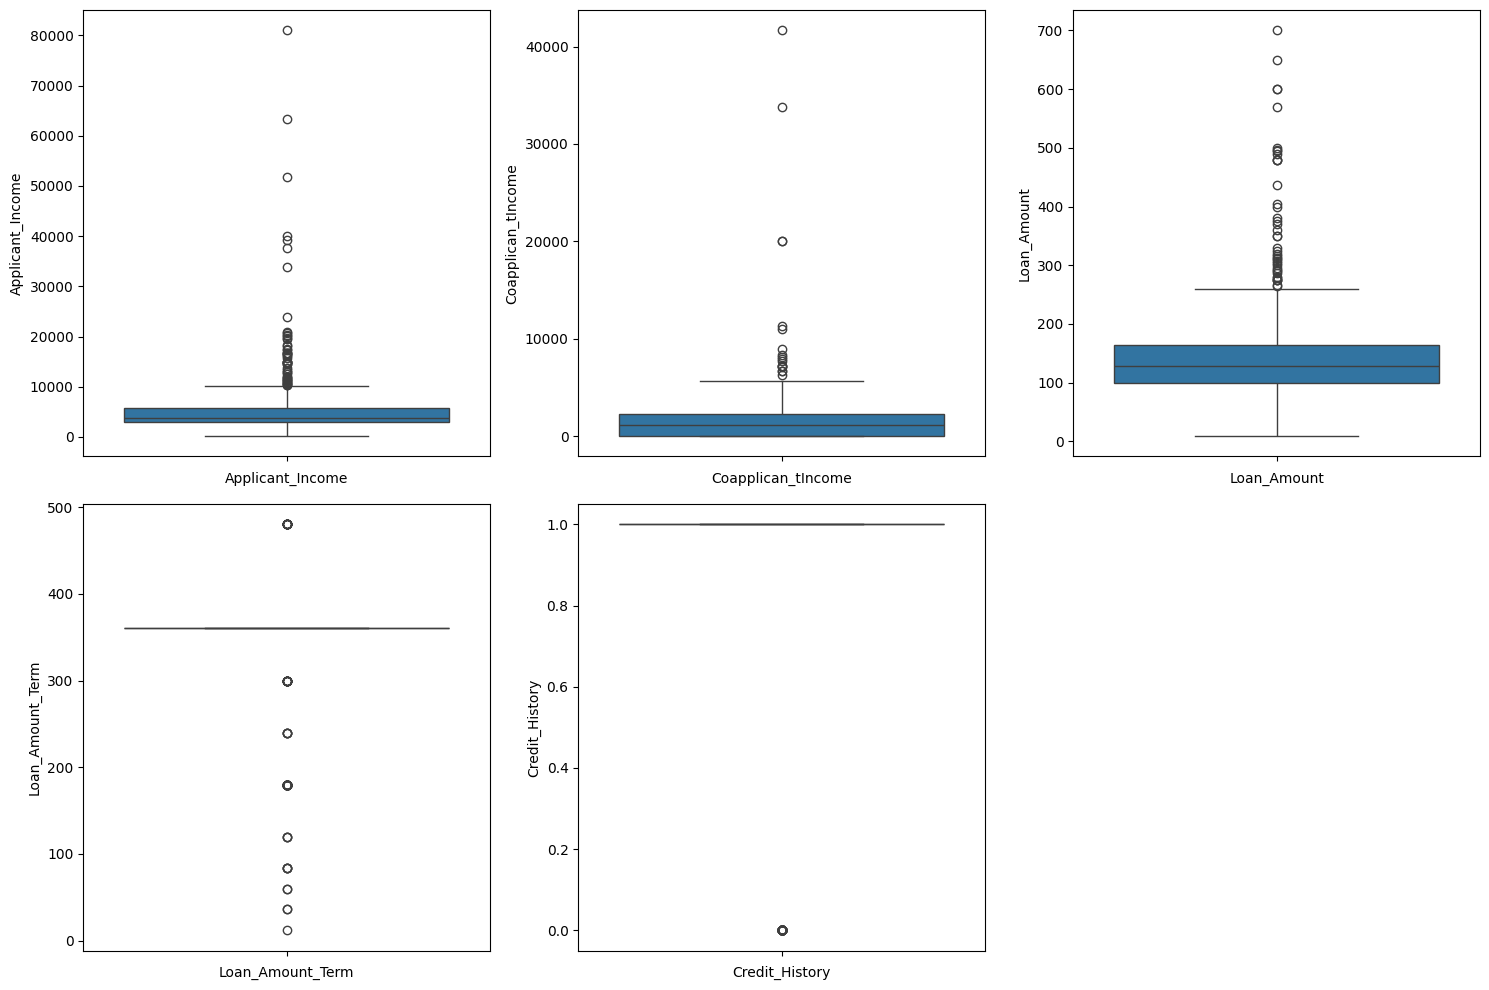

In [26]:
plt.figure(figsize=(15, 10), facecolor='white')
plotnumber = 1

for column in num_cols:
    if plotnumber <= len(num_cols):
        ax = plt.subplot(2, 3, plotnumber) # Adjust grid size as needed
        sns.boxplot(y=df[column], ax=ax)
        plt.xlabel(column, fontsize=10)
    plotnumber += 1

plt.tight_layout()
plt.show()

**Reasoning**:
To visually confirm that the outliers have been capped, I will generate box plots for all numerical columns. This will allow for a direct comparison with the previous box plots and demonstrate the effect of the capping.

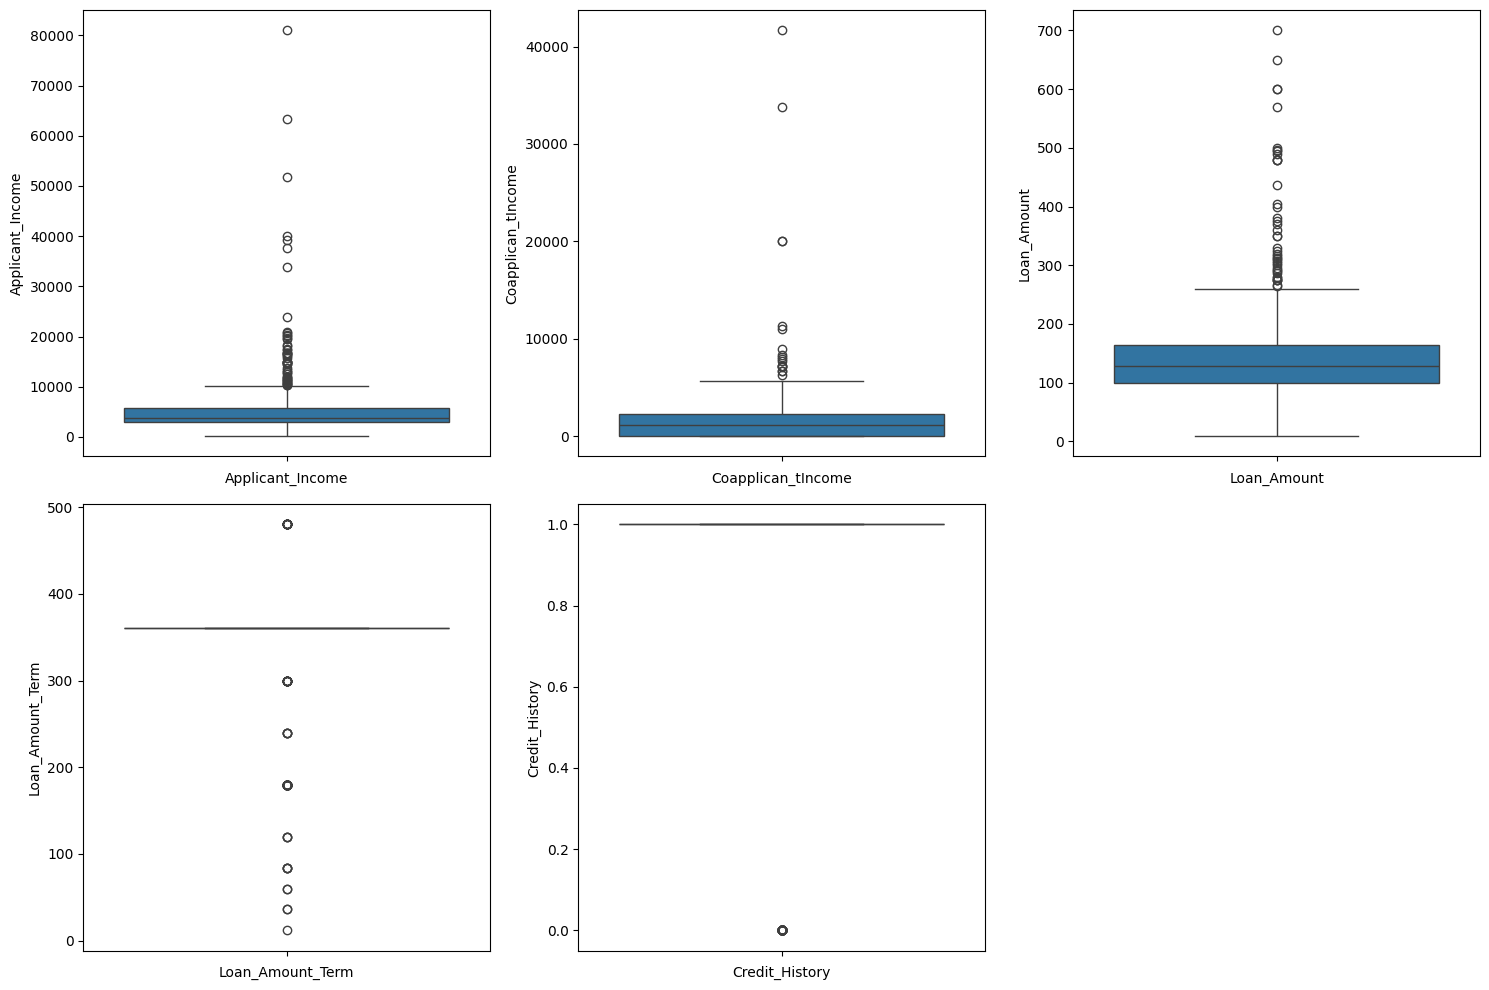

In [27]:
plt.figure(figsize=(15, 10), facecolor='white')
plotnumber = 1

for column in num_cols:
    if plotnumber <= len(num_cols):
        ax = plt.subplot(2, 3, plotnumber) # Adjust grid size as needed
        sns.boxplot(y=df[column], ax=ax)
        plt.xlabel(column, fontsize=10)
    plotnumber += 1

plt.tight_layout()
plt.show()

**Reasoning**:
First, we calculate the outlier bounds for each numerical column using the IQR method.

In [28]:
lower_bounds = {}
upper_bounds = {}

print("Outlier Bounds (IQR Method):")
for column in num_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    lower_bounds[column] = lower_bound
    upper_bounds[column] = upper_bound

    print(f"\nColumn: {column}")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")

Outlier Bounds (IQR Method):

Column: Applicant_Income
  Q1: 2877.50
  Q3: 5795.00
  IQR: 2917.50
  Lower Bound: -1498.75
  Upper Bound: 10171.25

Column: Coapplican_tIncome
  Q1: 0.00
  Q3: 2297.25
  IQR: 2297.25
  Lower Bound: -3445.88
  Upper Bound: 5743.12

Column: Loan_Amount
  Q1: 100.25
  Q3: 164.75
  IQR: 64.50
  Lower Bound: 3.50
  Upper Bound: 261.50

Column: Loan_Amount_Term
  Q1: 360.00
  Q3: 360.00
  IQR: 0.00
  Lower Bound: 360.00
  Upper Bound: 360.00

Column: Credit_History
  Q1: 1.00
  Q3: 1.00
  IQR: 0.00
  Lower Bound: 1.00
  Upper Bound: 1.00


**Reasoning**:
Now that the outlier bounds have been calculated, we cap the outliers in each numerical column using these bounds.

In [29]:
print("Capping outliers...")
for column in num_cols:
    df[column] = np.where(df[column] < lower_bounds[column], lower_bounds[column], df[column])
    df[column] = np.where(df[column] > upper_bounds[column], upper_bounds[column], df[column])
    print(f"Outliers in '{column}' capped.")
print("Outlier capping complete.")

Capping outliers...
Outliers in 'Applicant_Income' capped.
Outliers in 'Coapplican_tIncome' capped.
Outliers in 'Loan_Amount' capped.
Outliers in 'Loan_Amount_Term' capped.
Outliers in 'Credit_History' capped.
Outlier capping complete.


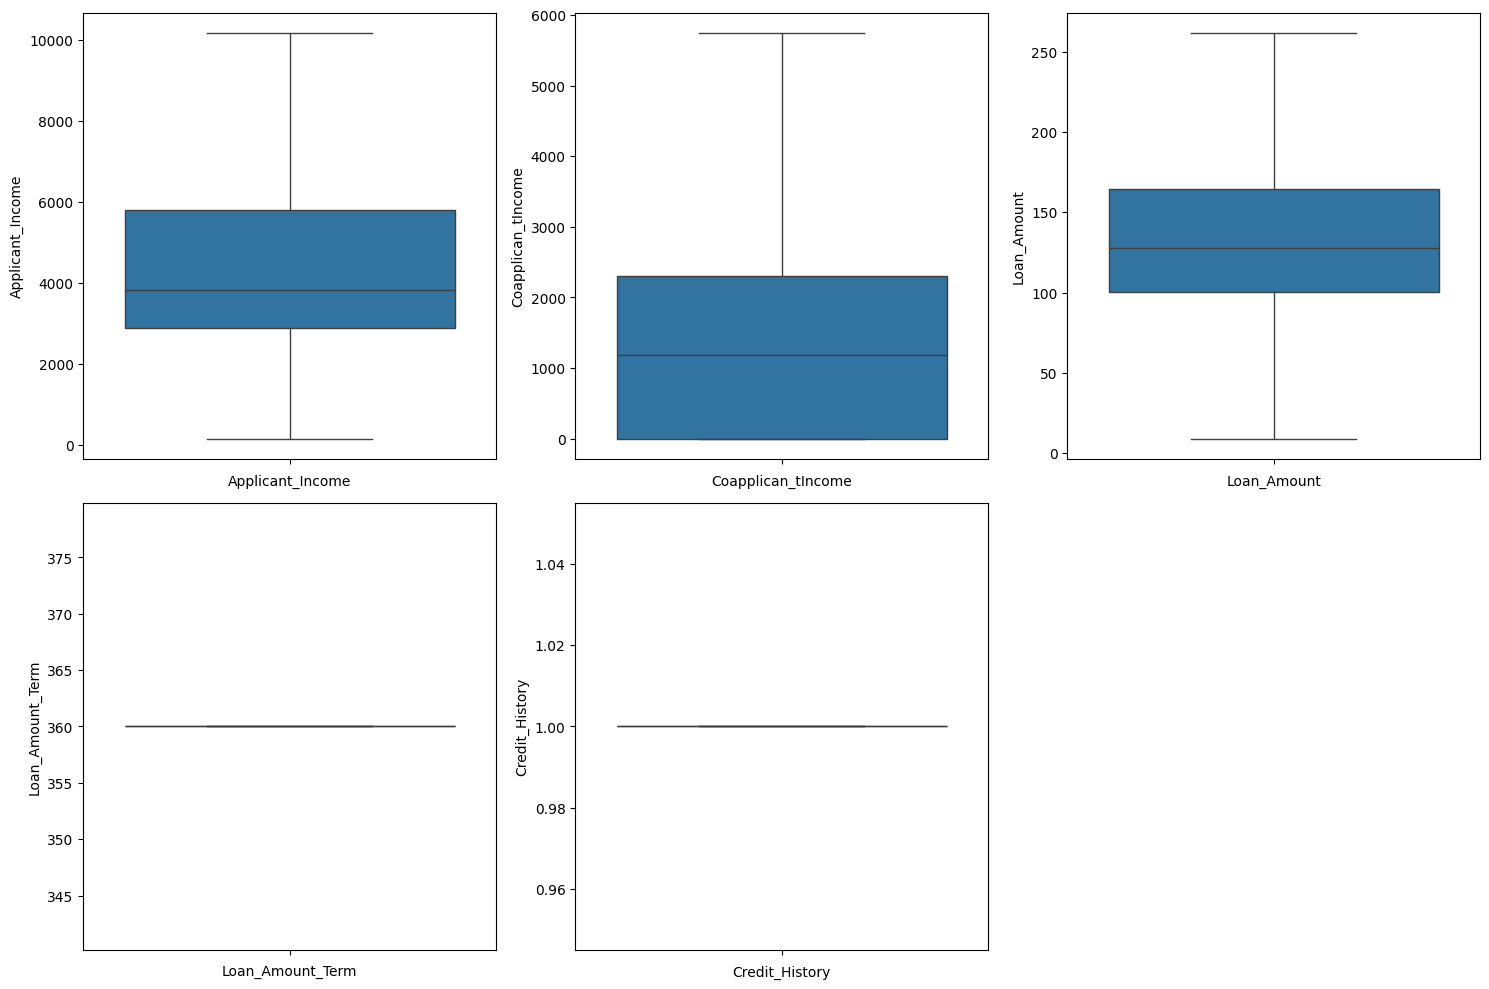

In [30]:
plt.figure(figsize=(15, 10), facecolor='white')
plotnumber = 1

for column in num_cols:
    if plotnumber <= len(num_cols):
        ax = plt.subplot(2, 3, plotnumber) # Adjust grid size as needed
        sns.boxplot(y=df[column], ax=ax)
        plt.xlabel(column, fontsize=10)
    plotnumber += 1

plt.tight_layout()
plt.show()

In [31]:
#

### Analyze Correlations Between Numerical Columns

In [32]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df[num_cols].corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Applicant_Income,Coapplican_tIncome,Loan_Amount,Loan_Amount_Term,Credit_History
Applicant_Income,1.000000,-0.228956,0.557953,NaN,NaN
Coapplican_tIncome,-0.228956,1.000000,0.265021,NaN,NaN
Loan_Amount,0.557953,0.265021,1.000000,NaN,NaN
Loan_Amount_Term,NaN,NaN,NaN,NaN,NaN
Credit_History,NaN,NaN,NaN,NaN,NaN


### Visualize the Correlation Matrix

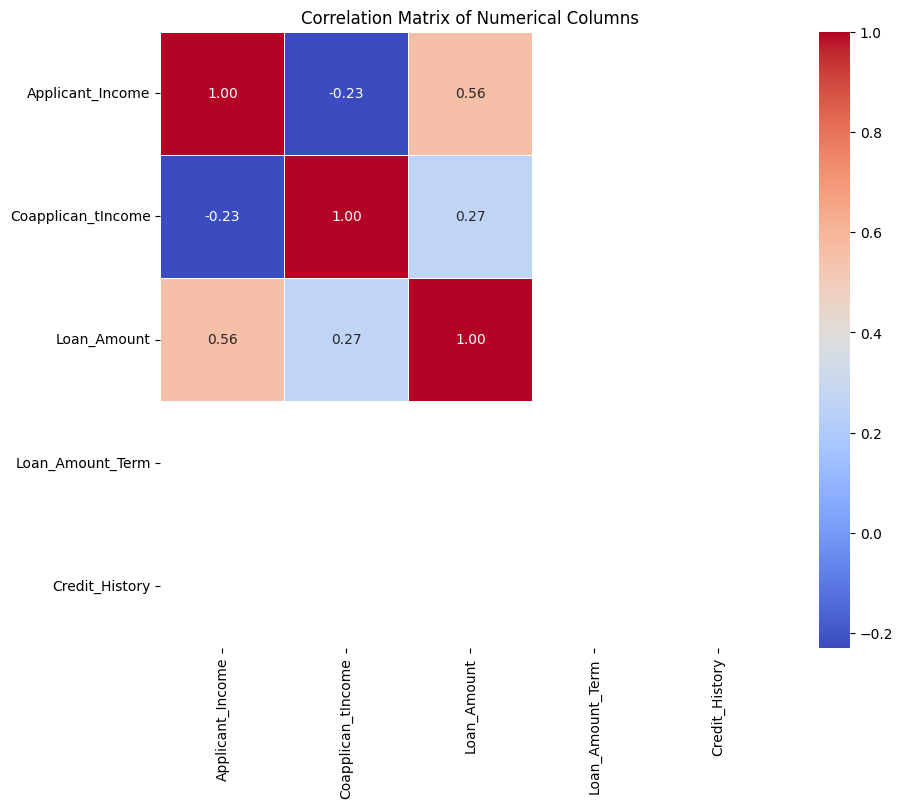

In [33]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

In [34]:
df.columns.tolist()

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Applicant_Income',
 'Coapplican_tIncome',
 'Loan_Amount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [35]:
target_cols='Loan_Status'

Using targer column Loan_Status


,count
Loan_Status,
Y,422
N,192


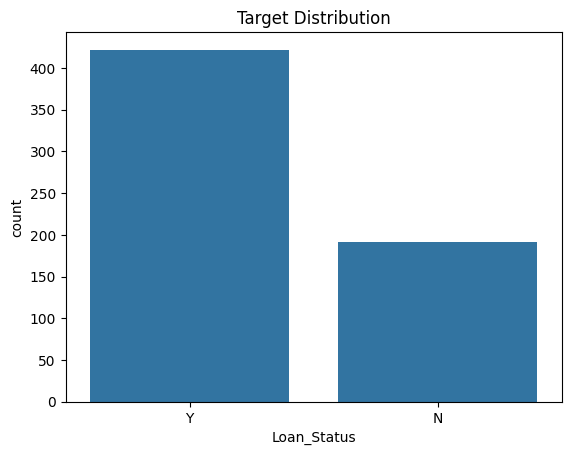

In [36]:
print('Using targer column',target_cols)
display(df[target_cols].value_counts(dropna=False))
sns.countplot(x=target_cols,data=df)
plt.title('Target Distribution')
plt.show()


In [37]:
# Split the data into X and y

In [73]:
df_clf = df.dropna(subset=[target_cols]).copy()

X = df_clf.drop(columns=[target_cols]) # Features
y = df_clf[target_cols] # Target variable

y = y.astype(str).str.strip().str.lower() # Convert to lowercase strings
y = (y == 'y').astype(int) # Convert 'y' to 1, 'n' to 0

In [75]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplican_tIncome,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban


In [76]:
y.head()

,Loan_Status
0,1
1,0
2,1
3,1
4,1


In [40]:
# preprocessing pipeline

In [77]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [78]:
numerical_transformer = Pipeline(steps=[
    ('impute',SimpleImputer(strategy=np.median)),
    ('scaler',StandardScaler())
])

In [45]:
numerical_transformer

Pipeline(steps=[('impute',
                 SimpleImputer(strategy=<function median at 0x7c2fb97111b0>)),
                ('scaler', StandardScaler())])

In [112]:
categorical_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('OneHotEncoder',OneHotEncoder(handle_unknown='ignore'))
])

In [96]:
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore'))])

In [119]:
cat_cols = [col for col in cat_cols if col != target_cols] # Exclude target column from categorical features

preprocess = ColumnTransformer(transformers=[
    ('num',numerical_transformer,num_cols),
    ('cat',categorical_transformer,cat_cols)
],remainder='drop')

In [120]:
preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy=<function median at 0x7c2fb97111b0>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Applicant_Income', 'Coapplican_tIncome',
                                  'Loan_Amount', 'Loan_Amount_Term',
                                  'Credit_History']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('OneHotEncoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Married', 'Dependents',
                                  'Education', 'Self_Employed',
                                  'Property_Area'])])

In [52]:
# Stage-1 RandomForest Classifier

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [123]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [124]:
X_train.shape

(491, 11)

In [125]:
X_test.shape

(123, 11)

In [126]:
rf_cls_pipepline= Pipeline(steps=[
    ('preprocessor',preprocess),
    ('rf_cls',RandomForestClassifier())
])

In [87]:
# Hyperparameter tuning

In [127]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [128]:
param_grid = {
    'rf_cls__n_estimators':[100,200,300,400],
    'rf_cls__max_depth':[None,4,8],
    'rf_cls__max_features':['sqrt',None]
}

In [129]:
grid = GridSearchCV(rf_cls_pipepline,param_grid,n_jobs=-1,cv=5,scoring='f1')
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy=<function median at 0x7c2fb97111b0>)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Applicant_Income',
                                                                          'Coapplican_tIncome',
                                                                          'Loan_Amount',
                                                                          'Loan_Amount_Term',
                                                                          'Credit_History']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImpu...trategy='most_frequent')),
                                                                                         ('OneHotEncoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Gender',
                                                                          'Married',
                                                                          'Dependents',
                                                                          'Education',
                                                                          'Self_Employed',
                                                                          'Property_Area'])])),
                                       ('rf_cls', RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'rf_cls__max_depth': [None, 4, 8],
                         'rf_cls__max_features': ['sqrt', None],
                         'rf_cls__n_estimators': [100, 200, 300, 400]},
             scoring='f1')

In [132]:
print('Best params(rf_cls) :', grid.best_params_)
best_clf = grid.best_estimator_
y_pred_best = best_clf.predict(X_test)
print(classification_report(y_pred_best,y_test))

Best params(rf_cls) : {'rf_cls__max_depth': 4, 'rf_cls__max_features': 'sqrt', 'rf_cls__n_estimators': 200}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.65      0.79       123

    accuracy                           0.65       123
   macro avg       0.50      0.33      0.39       123
weighted avg       1.00      0.65      0.79       123



In [133]:
# RandomForesrt final baseline model

In [136]:
rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor',preprocess),
   ('rf_cls', RandomForestClassifier(
       n_estimators =400,
       max_depth=None,
       max_features=None,
       random_state=10,
       oob_score=True))
])

In [137]:
rf_clf_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy=<function median at 0x7c2fb97111b0>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Applicant_Income',
                                                   'Coapplican_tIncome',
                                                   'Loan_Amount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('rf_cls',
                 RandomForestClassifier(max_features=None, n_estimators=400,
                                        oob_score=True, random_state=10))])

# Task
Cap outliers in the numerical columns of the DataFrame `df` using the IQR method, then display box plots for the numerical columns to visually confirm the outlier capping, and finally summarize the outlier handling process.

## Define Outlier Bounds (IQR Method)

### Subtask:
For each numerical column, calculate the first quartile (Q1), third quartile (Q3), and the Interquartile Range (IQR). Then, define upper and lower bounds for outlier detection using the formula: Lower Bound = Q1 - 1.5 * IQR and Upper Bound = Q3 + 1.5 * IQR.


**Reasoning**:
To define the outlier bounds for each numerical column, I will iterate through the numerical columns, calculate Q1, Q3, and IQR, and then compute the lower and upper bounds using the specified formulas. These bounds will be stored in dictionaries for later use and printed for inspection.



In [ ]:
lower_bounds = {}
upper_bounds = {}

print("Outlier Bounds (IQR Method):")
for column in num_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    lower_bounds[column] = lower_bound
    upper_bounds[column] = upper_bound

    print(f"\nColumn: {column}")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")

**Reasoning**:
Now that the outlier bounds have been calculated, I will cap the outliers in each numerical column using these bounds. Values below the lower bound will be set to the lower bound, and values above the upper bound will be set to the upper bound.



In [ ]:
print("Capping outliers...")
for column in num_cols:
    df[column] = np.where(df[column] < lower_bounds[column], lower_bounds[column], df[column])
    df[column] = np.where(df[column] > upper_bounds[column], upper_bounds[column], df[column])
    print(f"Outliers in '{column}' capped.")
print("Outlier capping complete.")

**Reasoning**:
To visually confirm that the outliers have been capped, I will generate box plots for all numerical columns. This will allow for a direct comparison with the previous box plots and demonstrate the effect of the capping.



In [ ]:
plt.figure(figsize=(15, 10), facecolor='white')
plotnumber = 1

for column in num_cols:
    if plotnumber <= len(num_cols):
        ax = plt.subplot(2, 3, plotnumber) # Adjust grid size as needed
        sns.boxplot(y=df[column], ax=ax)
        plt.xlabel(column, fontsize=10)
    plotnumber += 1

plt.tight_layout()
plt.show()

### Outlier Handling Summary

Outliers in the numerical columns of the DataFrame were handled using the Interquartile Range (IQR) method. For each numerical column, the following steps were performed:

1.  **Calculated Quartiles and IQR**: The first quartile (Q1), third quartile (Q3), and the Interquartile Range (IQR = Q3 - Q1) were calculated.
2.  **Defined Outlier Bounds**: Lower bounds (Q1 - 1.5 * IQR) and upper bounds (Q3 + 1.5 * IQR) were established to identify outliers.
3.  **Capped Outliers**: Values falling below the lower bound were set to the lower bound, and values exceeding the upper bound were set to the upper bound. This process effectively 'capped' the extreme values within a more reasonable range.
4.  **Visual Verification**: Box plots were generated for all numerical columns after capping to visually confirm the removal of outliers and ensure that the data distribution is now more contained without extreme points.

### Outlier Handling Summary

Outliers in the numerical columns of the DataFrame were handled using the Interquartile Range (IQR) method. For each numerical column, the following steps were performed:

1.  **Calculated Quartiles and IQR**: The first quartile (Q1), third quartile (Q3), and the Interquartile Range (IQR = Q3 - Q1) were calculated.
2.  **Defined Outlier Bounds**: Lower bounds (Q1 - 1.5 * IQR) and upper bounds (Q3 + 1.5 * IQR) were established to identify outliers.
3.  **Capped Outliers**: Values falling below the lower bound were set to the lower bound, and values exceeding the upper bound were set to the upper bound. This process effectively 'capped' the extreme values within a more reasonable range.
4.  **Visual Verification**: Box plots were generated for all numerical columns after capping to visually confirm the removal of outliers and ensure that the data distribution is now more contained without extreme points.

## Final Task

### Subtask:
Summarize the outlier handling process and the changes observed in the dataset after capping the outliers.


## Summary:

### Q&A
Outliers in the numerical columns of the DataFrame were handled using the Interquartile Range (IQR) method. This involved calculating Q1, Q3, and the IQR, then defining lower and upper bounds (Q1 - 1.5 \* IQR and Q3 + 1.5 \* IQR, respectively). Values falling outside these bounds were capped, meaning values below the lower bound were set to the lower bound, and values above the upper bound were set to the upper bound.

After capping, the dataset shows a more contained distribution for the numerical columns. Visual confirmation through box plots indicates that the extreme outlier points, which were previously visible, have been removed or brought within the defined bounds, thus making the data less susceptible to the undue influence of extreme values.

### Data Analysis Key Findings
*   Outliers in numerical columns (`Applicant_Income`, `Coapplicant_Income`, `Loan_Amount`, `Loan_Amount_Term`, `Credit_History`) were identified and capped using the IQR method.
*   For each numerical column, specific lower and upper bounds were calculated (e.g., `Applicant_Income` had a lower bound of -1498.75 and an upper bound of 10171.25).
*   The capping process successfully constrained extreme values, as confirmed by post-capping box plots which show a more contained data distribution without extended whiskers or isolated points far from the main data clusters.
*   All identified outliers were effectively adjusted to their respective calculated bounds, mitigating their potential disproportionate impact on subsequent analysis.

### Insights or Next Steps
*   The data is now preprocessed and more robust against the influence of extreme values, making it suitable for further statistical analysis or machine learning model training.
*   Consider evaluating the impact of this outlier capping strategy on model performance (if applicable) to ensure that this approach optimally serves the end goal of the analysis or prediction.
